<a href="https://colab.research.google.com/github/2xsec/2xsec.github.io/blob/master/03_Weight_Decomposition_Clustering_ipynb%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Weight Decomposition 실습**

# 0. Colab 환경설정
- colab에서 GPU를 사용할 수 있도록 세팅
    - 런타임 > 런타임 유형 변경 > Python 3 와 T4 GPU 선택

## 0-1. Setup
필요한 package를 import 합니다.

In [ ]:
! pip install tensorly==0.8.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.7/229.7 kB 6.3 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tensorly.decomposition import parafac  # Tensorly를 CP 분해를 위해 사용합니다.
import tensorly as tl
from tqdm import tqdm

# 1. 데이터 로드 및 모델/학습 관련 설정

## 1-1. MNIST 데이터셋 로드

In [ ]:
# Tensorly가 PyTorch 텐서와 함께 동작하도록 설정합니다.
tl.set_backend('pytorch')

# MNIST 데이터셋 로드
transform = transforms.Compose([
    transforms.ToTensor(),  # 데이터를 Tensor로 변환합니다.
    transforms.Normalize((0.1307,), (0.3081,))  # 정규화를 수행합니다.
])
train_dataset = datasets.MNIST(root='/content/data', train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)  # DataLoader를 설정합니다.

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 489kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.38MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.9MB/s]


## 1-2. CNN 모델 정의

In [ ]:
# CNN 모델 정의
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # 입력 채널 수는 1 (흑백 이미지), 출력 채널 수는 32, 커널 크기는 3, 스트라이드는 1, 패딩은 1로 설정합니다.
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        # 두 번째 합성곱 레이어를 정의합니다.
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        # 첫 번째 완전 연결 레이어를 정의합니다.
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        ###### [실습] 두 번째 완전 연결 레이어를 정의합니다. ######
        # MNIST dataset이므로 출력 클래스 수는 10 (0-9 숫자)로 설정합니다.
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # 첫 번째 합성곱 레이어 및 ReLU 활성화 함수를 적용합니다.
        x = F.relu(self.conv1(x))
        # 첫 번째 최대 풀링 적용
        x = F.max_pool2d(x, 2)
        # 두 번째 합성곱 레이어 및 ReLU 활성화 함수를 적용합니다.
        x = F.relu(self.conv2(x))
        # 두 번째 최대 풀링을 적용합니다.
        x = F.max_pool2d(x, 2)
        # 텐서를 평탄화하여 완전 연결 레이어에 입력할 준비를 합니다.
        x = x.view(-1, 64 * 7 * 7)
        # 첫 번째 완전 연결 레이어 및 ReLU 활성화 함수를 적용합니다.
        x = F.relu(self.fc1(x))
        # 두 번째 완전 연결 레이어 및 소프트맥스를 적용합니다.
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)  # 로그 소프트맥스를 반환합니다.

## 1-3. 모델, 손실함수, 옵티마이저 초기화

In [ ]:
# 모델, 손실 함수, 옵티마이저 초기화
model = SimpleCNN()  # 모델을 인스턴스화합니다.
criterion = nn.CrossEntropyLoss()  # 손실 함수를 정의합니다.
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adam 옵티마이저를 설정합니다.

## 1-4. Test dataset 로드

In [ ]:
# MNIST 테스트 데이터셋을 로드하여 검증을 위한 준비를 합니다.
test_dataset = datasets.MNIST(root='/content/data', train=False, transform=transform, download=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)  # DataLoader를 설정합니다.

## 1-5. Train, Validation 함수 정의

In [ ]:
def train(model, device, train_loader, optimizer, criterion):
    ###### [실습] 모델을 학습(train) 모드로 전환합니다. ######
    model.train()
    correct = 0
    for data, target in tqdm(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()  # 기울기를 초기화합니다.
        output = model(data)  # 모델을 통해 출력을 계산합니다.
        loss = criterion(output, target)  # 손실을 계산합니다.
        loss.backward()  # 역전파를 수행합니다.
        optimizer.step()  # 옵티마이저를 통해 파라미터를 업데이트합니다.
        # 학습 정확도를 계산합니다.
        pred = output.argmax(dim=1, keepdim=True)  # 가장 높은 점수를 가진 클래스 인덱스를 가져옵니다.
        correct += pred.eq(target.view_as(pred)).sum().item()
    accuracy = 100. * correct / len(train_loader.dataset)  # 전체 데이터셋에 대한 정확도를 계산합니다.
    ###### [실습] 정확도를 반환합니다. ######
    return accuracy

def validate(model, device, test_loader, criterion):
    ###### [실습] 모델을 평가(eval) 모드로 전환합니다. ######
    model.eval()
    test_loss = 0
    correct = 0  # 정확도를 계산하기 위한 변수입니다.
    with torch.no_grad():  # 그래디언트 계산을 비활성화합니다.
        for data, target in test_loader:  # 테스트 데이터에 대해 반복합니다.
            data, target = data.to(device), target.to(device)
            output = model(data)  # 모델을 통해 출력을 계산합니다.
            test_loss += criterion(output, target).item()  # 배치 손실을 합산합니다.
            pred = output.argmax(dim=1, keepdim=True)  # 가장 높은 점수를 가진 클래스 인덱스를 가져옵니다.
            correct += pred.eq(target.view_as(pred)).sum().item()
    accuracy = 100. * correct / len(test_loader.dataset)  # 전체 데이터셋에 대한 정확도를 계산합니다.
    ###### [실습] 정확도를 반환합니다. ######
    return accuracy

# 2. 학습 및 성능 측정

## 2-1. Train, Validation

In [ ]:
# 사용할 장치 설정 (GPU가 사용 가능하면 GPU를 사용합니다)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 학습 루프
num_epochs = 2  # 에폭 수를 설정합니다.
for epoch in range(1, num_epochs + 1):  # 각 에폭에 대해 반복합니다.
    ###### [실습] 학습 정확도와 validation 정확도를 계산합니다. ######
    ###### Hint: 위에서 구현한 함수들을 사용하여 정확도를 계산할 수 있습니다. ######
    train_accuracy = train(model, device, train_loader, optimizer, criterion)
    val_accuracy = validate(model, device, test_loader, criterion)
    print(f"Epoch {epoch}: Training Accuracy: {train_accuracy:.2f}% | Validation Accuracy: {val_accuracy:.2f}%")

100%|██████████| 938/938 [00:17<00:00, 52.47it/s]


Epoch 1: Training Accuracy: 95.66% | Validation Accuracy: 98.47%


100%|██████████| 938/938 [00:16<00:00, 57.92it/s]


Epoch 2: Training Accuracy: 98.66% | Validation Accuracy: 98.76%


## 2-2. batch 시간 측정

In [ ]:
import time
start = time.time()
###### [실습] 테스트 데이터로부터 첫번째(next) 배치를 가져옵니다. ######
data, target = next(iter(test_loader))
data, target = data.to(device), target.to(device)  # 데이터를 지정된 장치로 이동합니다.
output = model(data)
end = time.time()
print(f"Time for one batch: {end - start:.2f}s")
original_time = end - start

Time for one batch: 0.20s


## 2-3. 원래 모델의 정확도 측정

In [ ]:
def reset_weights(model, pure_param):
    for name, param in model.named_parameters():
        if name == 'fc1.weight':
            param.data = pure_param.clone()  # 주어진 파라미터를 클론하여 가중치를 초기화합니다.
    return model  # 수정된 모델을 반환합니다.

pure_weights = model.fc1.weight.data.clone()
original_weights_full = {}  # 모든 원래 가중치를 저장하기 위한 딕셔너리를 초기화합니다.
for name, param in model.named_parameters():
    original_weights_full[name] = param.data.clone()  # 각 파라미터의 클론을 딕셔너리에 저장합니다.

# 원래 모델의 validation 정확도를 계산합니다.
val_accuracy = validate(model, device, test_loader, criterion)
print(f"Original Model's Validation Accuracy: {val_accuracy:.2f}%")

Original Model's Validation Accuracy: 98.76%


# 3. CP 분해

## 3-1. CP 분해 관련 함수 정의

In [ ]:
# 첫 번째 fc layer의 가중치에 CP 분해를 적용하는 함수
def cp_decompose_fc1_weights(model, rank):
    # 첫 번째 fc layer의 가중치를 가져옵니다.
    weights = model.fc1.weight.data
    # CP 분해를 수행합니다.
    ###### [실습] Tensorly에서 CP 분해를 수행하는 함수 parafac()으로 CP 분해를 수행합니다. ######
    factors = parafac(pure_weights, rank=rank)
    return factors  # 분해된 인자를 반환합니다.

# CP 분해 인자로부터 가중치를 재구성하는 함수
def reconstruct_weights_from_cp(factors):
    reconstructed_weights = tl.kruskal_to_tensor(factors)  # kruskal tensor에서 재구성된 가중치를 얻습니다.
    ###### [실습] 재구성된 가중치를 반환합니다. ######
    return reconstructed_weights

## 3-2. CP 분해 적용 및 재구성 오차(MSE) 계산

In [ ]:
# 두 번째 실행을 위해 모델의 가중치를 초기화합니다.
reset_weights(model, pure_weights)

# CP 분해의 랭크를 설정합니다.
rank = 10  # 예시 랭크, 조정 가능합니다.

###### [실습] CP 분해를 적용합니다. ######
# cp_decompose_fc1_weights() 함수를 사용하여 모델의 fc1 레이어 가중치에 CP 분해를 적용하고, 분해된 인자를 얻습니다.
factors = cp_decompose_fc1_weights(model, rank)

###### [실습] 가중치를 재구성합니다. ######
# reconstruct_weights_from_cp() 함수를 사용하여 분해된 인자로부터 가중치를 재구성합니다.
reconstructed_weights = reconstruct_weights_from_cp(factors)

# 원래 가중치와 재구성된 가중치 간의 평균 제곱 오차를 계산합니다.
mse = torch.mean((model.fc1.weight.data - reconstructed_weights) ** 2)
print(f"Mean Square Error between original and reconstructed weights: {mse}")

# 재정의된 모델, 가중치를 가져오되, 분해된 텐서를 활용합니다.
other_weights = {}  # 다른 가중치를 저장할 딕셔너리를 초기화합니다.
for name, param in model.named_parameters():
    if name != 'fc1.weight':  # 'fc1.weight'를 제외한 파라미터만 저장합니다.
        other_weights[name] = param.data.clone()  # 각 파라미터의 클론을 저장합니다.

Mean Square Error between original and reconstructed weights: 0.00024472278892062604


## 3-3. 분해된 가중치를 적용한 모델 재정의

In [ ]:
# 분해된 가중치를 사용하여 모델을 재정의합니다.
class SimpleCNN(nn.Module):
    def __init__(self, new_weights=None):   # 새로운 가중치를 받아오는 생성자를 정의합니다.
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

        ###### [실습] 새로운 가중치(new_weights)가 주어졌다면 ######
        if new_weights is not None:
            recon_weights = reconstruct_weights_from_cp(new_weights)    # 분해된 가중치를 재구성합니다.
            self.fc1.weight.data = recon_weights.clone().detach()

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = x.view(-1, 64 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)  # 로그 소프트맥스를 반환합니다.

## 3-4. 분해된 가중치를 적용한 모델 초기화

In [ ]:
# 새로운 가중치를 사용하여 모델을 재초기화합니다.
model = SimpleCNN(new_weights=factors)  # 분해된 가중치를 이용하여 모델 인스턴스를 생성합니다.

for name, param in model.named_parameters():
    if name != 'fc1.weight':  # 'fc1.weight'를 제외한 파라미터에 대해서
        param.data = other_weights[name].clone()  # 원래의 가중치를 클론하여 할당합니다.

model.to(device)

SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

## 3-5. 성능 및 속도 비교

In [ ]:
print(f"Original Shape was {model.fc1.weight.shape}")  # 원래 가중치의 형태를 출력합니다.
print(f"Decomposed shapes are {factors.factors[0].shape},{factors.factors[1].shape}")  # 분해된 인자의 형태를 출력합니다.
print(f"Original number of elements in weight was {torch.numel(model.fc1.weight)}")  # 원래 가중치의 원소 개수를 출력합니다.
print(f"Number of elements in decomposed weights is {torch.numel(factors.factors[0]) + torch.numel(factors.factors[1])}")  # 분해된 가중치의 원소 개수를 출력합니다.

val_accuracy_after_decomp = validate(model, device, test_loader, criterion)  #  분해 후 validation accuracy를 계산합니다.
print(f"Validation Accuracy after CP Decomposition: {val_accuracy_after_decomp:.2f}%")

# CP 분해 시간을 확인합니다.
start = time.time()
data, target = next(iter(test_loader))
data, target = data.to(device), target.to(device)
output = model(data)
end = time.time()
print(f"Time for one batch: {end - start:.2f}s")
cp_decomp_time = end - start

Original Shape was torch.Size([128, 3136])
Decomposed shapes are torch.Size([128, 10]),torch.Size([3136, 10])
Original number of elements in weight was 401408
Number of elements in decomposed weights is 32640
Validation Accuracy after CP Decomposition: 98.19%
Time for one batch: 0.19s


# **Weight Clustering**

# 4. Weight Clustering

## 4-1. Weight Clustering 관련 함수 정의
가중치를 K-Means 알고리즘으로 군집화하여,
각 가중치를 가장 가까운 클러스터 중심값으로 치환합니다.
이를 통해 모델의 가중치 표현을 단순화하고 압축 효과를 얻을 수 있습니다.

In [ ]:
import numpy as np
from sklearn.cluster import KMeans

def weight_clustering(weights, n_clusters):

    weights_np = weights.cpu().numpy().astype(np.float32)  # 가중치를 float32 형식의 NumPy 배열로 변환합니다.

    # 클러스터링을 수행합니다.
    from sklearn.cluster import KMeans

    original_shape = weights_np.shape  # 원래 가중치의 형태를 저장합니다.
    weights_flat = weights_np.reshape(-1, 1)

    # KMeans 클러스터링을 적용합니다.
    ###### [실습] 전달받은 클러스터 개수(n_clusters)로 KMeans 객체를 생성합니다. ######
    kmeans = KMeans(n_clusters=n_clusters)
    kmeans.fit(weights_flat)

    # 클러스터링된 중심점을 가져옵니다.
    clustered_weights = kmeans.cluster_centers_[kmeans.labels_]
    clustered_weights = clustered_weights.reshape(original_shape)

    return torch.tensor(clustered_weights, dtype=torch.float32).to(weights.device)  # 텐서로 변환하여 원래 장치로 반환합니다.

## 4-2. Weight Clustering 적용
FC Layer의 가중치에 Weight Clustering을 적용합니다.
클러스터 개수를 지정하고, 군집 중심값으로 가중치를 재구성합니다.

In [ ]:
original_weights = model.fc1.weight.data.clone()  # 원래 가중치를 저장합니다.

# weight clustering을 적용하기 전에 가중치를 초기화합니다.
model.fc1.weight.data = original_weights.clone()

# weight clustering을 적용합니다.
n_clusters = 10  # 클러스터링을 위한 클러스터 수를 지정합니다.
###### [실습] 지정한 클러스터 개수(n_clusters)를 사용하여 Weight Clustering을 수행합니다. ######
clustered_weights = weight_clustering(model.fc1.weight.data, n_clusters)
model.fc1.weight.data = clustered_weights  # 클러스터링된 가중치로 업데이트합니다.

## 4-3. Clustering 결과 시각화
원본 가중치와 Clustering 적용 후 가중치의 분포를 시각화하여
Weight Clustering의 효과를 확인합니다.

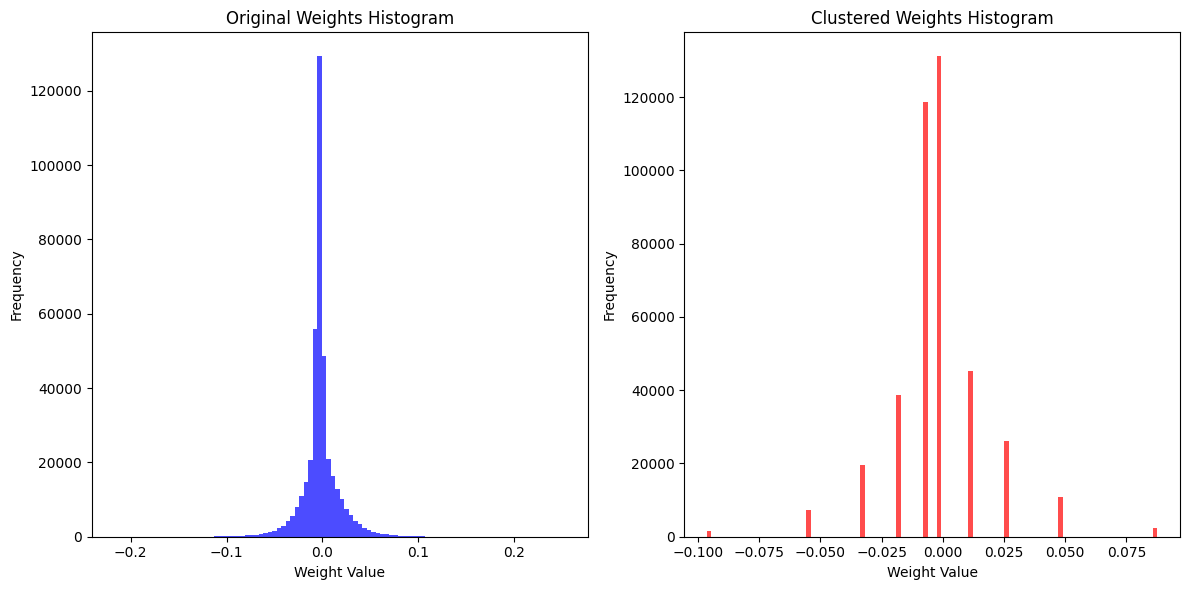

In [ ]:
import matplotlib.pyplot as plt

def plot_weights(original_weights, clustered_weights):
    plt.figure(figsize=(12, 6))  # 그래프의 크기를 설정합니다.

    # 원래 가중치 플롯
    plt.subplot(1, 2, 1)  # 1행 2열의 첫 번째 서브플롯을 설정합니다.
    plt.hist(original_weights.view(-1).cpu().detach().numpy(), bins=100, color='blue', alpha=0.7)  # 원래 가중치의 히스토그램을 그립니다.
    plt.title('Original Weights Histogram')  # 제목을 설정합니다.
    plt.xlabel('Weight Value')  # x축 레이블을 설정합니다.
    plt.ylabel('Frequency')  # y축 레이블을 설정합니다.

    # 클러스터링된 가중치 플롯
    plt.subplot(1, 2, 2)  # 1행 2열의 두 번째 서브플롯을 설정합니다.
    plt.hist(clustered_weights.view(-1).cpu().detach().numpy(), bins=100, color='red', alpha=0.7)  # 클러스터링된 가중치의 히스토그램을 그립니다.
    plt.title('Clustered Weights Histogram')  # 제목을 설정합니다.
    plt.xlabel('Weight Value')  # x축 레이블을 설정합니다.
    plt.ylabel('Frequency')  # y축 레이블을 설정합니다.

    plt.tight_layout()  # 서브플롯 간의 간격을 조정합니다.
    plt.show()  # 그래프를 화면에 표시합니다.


# 원래 가중치와 클러스터링된 가중치를 플롯합니다.
plot_weights(original_weights, clustered_weights)

## 4-4. 성능 평가
Weight Clustering 적용 후 Validation Accuracy를 측정하여
모델 성능 변화를 확인합니다.

In [ ]:
val_acc_after = validate(model, device, test_loader, criterion)
print(f"Validation Accuracy after Weight Clustering: {val_acc_after:.2f}%")

start = time.time()
data, target = next(iter(test_loader))
data, target = data.to(device), target.to(device)
output = model(data)
end = time.time()
print(f"Time for one batch: {end - start:.2f}s")
weight_clustering_time = end - start

Validation Accuracy after Weight Clustering: 98.00%
Time for one batch: 0.20s


## 4-5. 실행 시간 비교
Original 모델, CP Decomposition 모델,
Weight Clustering 모델의 추론 시간을 비교합니다.

In [ ]:
# Original, CP 분해, Weight clustering 시간을 비교합니다.
print(f"Original Time: {original_time:.5f}s")
print(f"CP Decomposition Time: {cp_decomp_time:.5f}s")
print(f"Weight Clustering Time: {weight_clustering_time:.5f}s")

Original Time: 0.19831s
CP Decomposition Time: 0.19066s
Weight Clustering Time: 0.19798s
